t_lin: torch.Size([1, 1, 8, 8])
t_lin2: torch.Size([1, 2, 8, 8])

t_cub: torch.Size([1, 1, 8, 8])
t_cub2: torch.Size([1, 2, 8, 8])
diff: tensor(0.) tensor(0.)


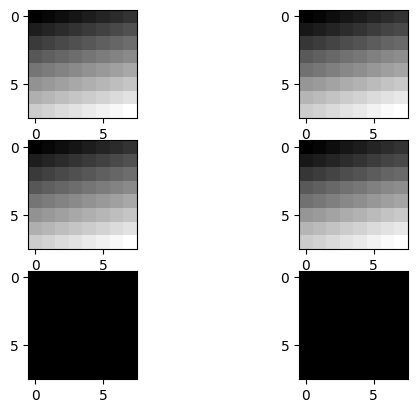

In [9]:
import torch
from torch import nn
import matplotlib.pyplot as plt

t = torch.arange(16).reshape(4, 4).float()
t_cub = nn.Upsample(scale_factor=2, mode='bicubic', align_corners=True)(t[None, None])
t_lin = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)(t[None, None])


t = torch.stack((t, 2*t))
t_cub2 = nn.Upsample(scale_factor=2, mode='bicubic', align_corners=True)(t[None])
t_lin2 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)(t[None])

print('t_lin:', t_lin.shape)
print('t_lin2:', t_lin2.shape)

print('\nt_cub:', t_cub.shape)
print('t_cub2:', t_cub2.shape)

fig, axs = plt.subplots(ncols=2, nrows=3)

vmax = max(t_lin[0, 0].max(), t_lin2[0, 0].max())
axs[0][0].imshow(t_lin[0, 0], cmap='gray', vmax=vmax)
axs[1][0].imshow(t_lin2[0, 0], cmap='gray', vmax=vmax)
axs[2][0].imshow(t_lin2[0, 0]-t_lin[0, 0], cmap='gray')

diff = t_cub2[0, 0]-t_cub[0, 0]
print('diff:', diff.min(), diff.max())
vmax = max(t_cub[0, 0].max(), t_cub2[0, 0].max())
axs[0][1].imshow(t_cub[0, 0], cmap='gray', vmax=vmax)
axs[1][1].imshow(t_cub2[0, 0], cmap='gray', vmax=vmax)
axs[2][1].imshow(diff, cmap='gray')

In [19]:
import torch
from torch import nn
import matplotlib.pyplot as plt

x = torch.linspace(0, 1, 1000)
y = 3. + x * (5 + x*( -2 - x*5))


class Estimator(nn.Module):
    def __init__(self, size, size_sub):
        super().__init__()
        self.l1 = nn.Linear(size, size_sub)
        self.l2 = nn.Linear(size_sub, size_sub)
        self.l3 = nn.Linear(size_sub, size)
        self.activation = nn.Mish(inplace=True)
    
    def forward(self, x):
        return self.l3(
            self.activation(
                self.l2(
                    self.activation(
                        self.l1(x)
                    )
                )
            )
        )


loss_fn = nn.MSELoss()

torch.manual_seed(0)
estimator = Estimator(len(x), 100)
torch.manual_seed(0)
estimator2 = Estimator(len(x), 100)

estimator.train()
estimator2.train()
losses, losses2 = [], []
optimizer = torch.optim.Adam(estimator.parameters())
optimizer2 = torch.optim.Adam(estimator2.parameters())
epochs = 100
for i in range(epochs):
    print(f'{i/epochs:.1%}', end='\r')
    optimizer.zero_grad()
    loss = loss_fn(estimator(x)*10, y*10)
    losses.append(loss.item())
    loss.backward()
    optimizer.step()

    optimizer2.zero_grad()
    loss = loss_fn(estimator2(x), y)
    losses2.append(loss.item())
    loss.backward()
    optimizer2.step()
    
print(' '*20)


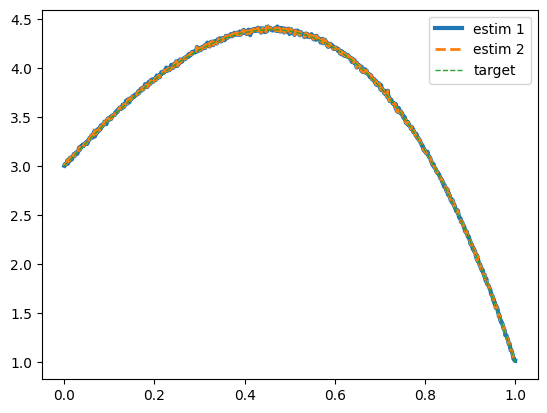

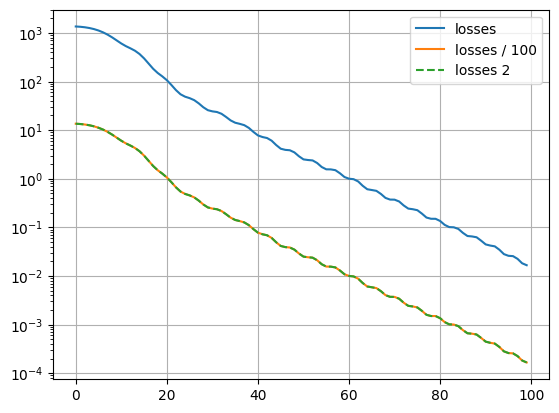

In [23]:
estimator.eval()
estimator2.eval()
fig, ax = plt.subplots()
ax.plot(x, estimator(x).detach(), linewidth=3, label='estim 1')
ax.plot(x, estimator2(x).detach(), '--', linewidth=2, label='estim 2')
ax.plot(x, y, '--', linewidth=1, label='target')
ax.legend()

fig, ax = plt.subplots()
ax.semilogy(losses, label='losses')
ax.semilogy(torch.tensor(losses)*0.01, label='losses / 100')
ax.semilogy(losses2, '--', label='losses 2')
ax.grid()
ax.legend()

In [38]:
import funcs
import os

path_data = '/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/07_POC/data/results/'

files = os.listdir(path_data)
print('files:\n', files)
for filename in files:
    data = funcs.load_pickle(path_data + filename[:-7])
    print('keys:', data.keys())
    for key, lst in data['loss'].items():
        data['loss'][key] = [value*0.01 for value in data['loss'][key]]
    funcs.to_pickle(path_data + filename[:-7], data)

files:
 ['initial.pickle', 'GroupNorm-1.pickle', 'GroupNorm-1-2.pickle', 'GroupNorm-4.pickle', 'GroupNorm-8.pickle', 'GroupNorm-8-2.pickle', 'GroupNorm-4-2.pickle', 'Mish-GN-4.pickle', 'Mish-GN-4-SepConv1.pickle', 'Mish-GN-4-SepConv1-ResNeXt-4.pickle', 'DenseConv.pickle']
keys: dict_keys(['metric label', 'metric', 'loss', 'lr', 'confusion', 'compute time'])
keys: dict_keys(['metric label', 'metric', 'loss', 'lr', 'confusion', 'compute time'])
keys: dict_keys(['metric label', 'metric', 'loss', 'lr', 'confusion', 'compute time'])
keys: dict_keys(['metric label', 'metric', 'loss', 'lr', 'confusion', 'compute time'])
keys: dict_keys(['metric label', 'metric', 'loss', 'lr', 'confusion', 'compute time'])
keys: dict_keys(['metric label', 'metric', 'loss', 'lr', 'confusion', 'compute time'])
keys: dict_keys(['metric label', 'metric', 'loss', 'lr', 'confusion', 'compute time'])
keys: dict_keys(['metric label', 'metric', 'loss', 'lr', 'confusion', 'compute time'])
keys: dict_keys(['metric label'

In [43]:
import torch
t = torch.arange(12).reshape(1, 3, 4)
t2 = torch.cat((t, 2*t))
t2

tensor([[[ 0,  1,  2,  3],
         [ 4,  5,  6,  7],
         [ 8,  9, 10, 11]],

        [[ 0,  2,  4,  6],
         [ 8, 10, 12, 14],
         [16, 18, 20, 22]]])

In [45]:
class TestClass():
    a = 2
    b = a + a
    def __init__(self):
        print('a:', TestClass.a)
        print('b:', TestClass.b)

TestClass()

a: 2
b: 4


In [46]:
import time
import torch

n = 50000

t = torch.empty(n, dtype=torch.float)

t0 = time.time()
for i in torch.arange(n):
    t[i] = i
print('elapsed time:', time.time()-t0)

t0 = time.time()
[t[i] = i for i in torch.arange(n)]
print('elapsed time:', time.time()-t0)

SyntaxError: cannot assign to subscript here. Maybe you meant '==' instead of '='? (3361946477.py, line 14)

In [49]:
import torch
t = torch.arange(12).reshape(1, 1, 3, 4)

torch.cat( (t, t), dim=1 )

tensor([[[[ 0,  1,  2,  3],
          [ 4,  5,  6,  7],
          [ 8,  9, 10, 11]],

         [[ 0,  1,  2,  3],
          [ 4,  5,  6,  7],
          [ 8,  9, 10, 11]]]])